<a href="https://colab.research.google.com/github/Silva015/tcc-2026/blob/main/Entrada-Saida-ResNet152%2BKAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Ferimentos Balísticos com Transfer Learning e Redes KAN
Uso do resNet152 para detecção de cancer de intestino
Utilizamos a arquitetura **ResNet152** pré-treinada para a extração de características espaciais e substituímos o classificador tradicional (MLP) por uma **Kolmogorov-Arnold Network (KAN)** para a tomada de decisão.


In [2]:
!pip install git+https://github.com/Blealtan/efficient-kan -q


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import os
from glob import glob
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.models as models
from efficient_kan import KAN
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tqdm
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import kagglehub
import shutil
from typing import Tuple
from PIL import Image
from imblearn.combine import SMOTETomek
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc
from tabulate import tabulate
import seaborn as sns
import copy
# Imports do Albumentations para Data Augmentation Avançado
import albumentations as A
from albumentations.pytorch import ToTensorV2



In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"Using: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("CUDA is not available. Using CPU.")


Using: NVIDIA A100-SXM4-40GB
CUDA: 12.6


In [5]:
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
shutil.copytree(path, "/content/", dirs_exist_ok=True)
!ls lung_colon_image_set

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
colon_image_sets  lung_image_sets


In [6]:
def generate_csv(path):
    path_to_dataset = pathlib.Path(path)
    LC25000Formatter(input_path = path_to_dataset, output_csv = "nb_lc25000.csv").run()


def get_formatted_datasets(path="/content/lung_colon_image_set/colon_image_sets", csv_path="/content/nb_lc25000.csv"):
    generate_csv(path)

    dataframe = pd.read_csv(csv_path)
    x_train, x_test, y_train, y_test = train_test_split(
        dataframe["path"],
        dataframe["label"],
        test_size=0.2,
        random_state=42,
        stratify=dataframe["label"]
    )

    df_train = pd.DataFrame({"path": x_train, "label": y_train})
    df_test = pd.DataFrame({"path": x_test, "label": y_test})  

    X_train, X_validation, y_train, y_validation = train_test_split(
    df_train["path"],
    df_train["label"],
    test_size=0.1,
    random_state=42,
    stratify=df_train["label"]
    )

    df_train = pd.DataFrame({"path": X_train, "label": y_train})
    df_validation = pd.DataFrame({"path": X_validation, "label": y_validation})


    return df_train, df_validation, df_test

class LC25000Formatter:
    def __init__(self, input_path, output_csv):
        self.input_path = input_path
        self.output_csv_path = output_csv

    def run(self):
        df = self.process_directory(self.input_path)
        df.to_csv(self.output_csv_path, index=False)
        print(f"CSV salvo com sucesso em: {self.output_csv_path}")

    def process_directory(self, input_path: str):
        label_map = {
            "colon_n": int(0),
            "colon_aca": int(1)
        }
        image_extensions = ['.jpg', '.jpeg', '.png']
        image_paths = list(self.input_path.glob('**/*'))

        data = []
        for path in tqdm.tqdm(image_paths):
            if path.suffix.lower() in image_extensions and path.is_file():
                label = path.parent.name
                segmentation = path.parent.name
                data.append({
                    "path": str(path.resolve()),
                    "label": label_map[label],
                    "segmentation": segmentation
                })

        df = pd.DataFrame(data)
        return df

In [7]:
class LC25000Dataset(Dataset):
    def __init__(self, df, target_column, transforms=None):
        self._df = df.reset_index(drop=True)
        self._target_column = target_column
        self._transforms = transforms

    def __len__(self):
        return len(self._df)

    def __getitem__(self, idx):
        row = self._df.iloc[idx]
        image_file_path = row["path"]


        if not os.path.exists(image_file_path):
            raise FileNotFoundError(f"Imagem não encontrada: {image_file_path}")

        image = Image.open(image_file_path).convert("RGB")
        image = np.array(image)
        if self._transforms is not None:
            image = self._transforms(image=image)["image"]
        label = row[self._target_column]
        return image, label

    def show_img(self, idx):
        '''Plot image'''
        img, label = self.__getitem__(idx)
        if isinstance(img, torch.Tensor):
            img = img.numpy().transpose(1, 2, 0)
        plt.figure(figsize=(16, 8))
        plt.axis('off')
        plt.imshow(img)
        plt.title(label)
        plt.pause(0.001)

class LC25000DatasetMemory(Dataset):
    def __init__(self, dataframe, transforms=None, target_column="label"):
        self.dataframe = dataframe
        self.transforms = transforms
        self.target_column = target_column

        self.images = []
        self.labels = []

        for idx, row in dataframe.iterrows():
            image_path = row["path"]
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            if self.transforms:
                transformed = self.transforms(image=image_np)
                image_tensor = transformed["image"]
            else:
                image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)  # fallback

            self.images.append(image_tensor)
            self.labels.append(row[target_column])

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


class LC25000DatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

def get_dataloaders(df_train, df_validation, df_test, batch_size = 1, num_workers = 0, memory_mode = False):
    if not memory_mode:
        dataset_train = LC25000Dataset(
            df_train,
            transforms=LC25000DatasetConfig.TRAIN_TRANSFORMS,
            target_column="label",
        )

        dataset_validation = LC25000Dataset(
            df_validation,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataset_test = LC25000Dataset(
            df_test,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataloader_train = DataLoader(dataset_train, batch_size= batch_size,pin_memory = True, shuffle= True, num_workers = num_workers)
        dataloader_validation = DataLoader(dataset_validation, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)
        dataloader_test = DataLoader(dataset_test, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)

        return dataloader_train, dataloader_validation, dataloader_test

    else:
        dataset_train = LC25000DatasetMemory(
            df_train,
            transforms=LC25000DatasetConfig.TRAIN_TRANSFORMS,
            target_column="label",
        )

        dataset_validation = LC25000DatasetMemory(
            df_validation,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataset_test = LC25000DatasetMemory(
            df_test,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataloader_train = DataLoader(dataset_train, batch_size= batch_size,pin_memory = True, shuffle= True, num_workers = num_workers)
        dataloader_validation = DataLoader(dataset_validation, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)
        dataloader_test = DataLoader(dataset_test, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)

        return dataloader_train, dataloader_validation, dataloader_test

In [8]:
df_train, df_validation, df_test = get_formatted_datasets()
print(f"\nNumber of images in training dataset: {len(df_train)}")
print(f"Number of images in test dataset: {len(df_validation)}")
print(f"Number of images in validation dataset: {len(df_test)}")

100%|██████████| 10002/10002 [00:00<00:00, 25798.20it/s]


CSV salvo com sucesso em: nb_lc25000.csv

Number of images in training dataset: 7200
Number of images in test dataset: 800
Number of images in validation dataset: 2000


In [9]:
batch_size = 64
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test, batch_size, 2, memory_mode = True)

In [10]:
class TransferKAN_Gunshot(nn.Module):
    def __init__(self):
        super(TransferKAN_Gunshot, self).__init__()

        # Extrator de Características: ResNet152
        resnet = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.flat_size = 2048

        # Regularização
        self.dropout = nn.Dropout(p=0.5)

        # Classificador KAN: Aumentando o grid_size para 10 (padrão é 5) para captar
        # mais nuances não-lineares, com ordem da spline = 3 (cúbica)
        self.kan = KAN([self.flat_size, 128, 2], grid_size=10, spline_order=3)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.kan(x)
        return x

model = TransferKAN_Gunshot().to(device)
print(f"🚀 Modelo TransferKAN_Gunshot inicializado e enviado para: {device.type.upper()}")

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 225MB/s]  


🚀 Modelo TransferKAN_Gunshot inicializado e enviado para: CUDA


In [11]:
criterion = torch.nn.CrossEntropyLoss()
def train_model_two_phases(model, dataloader_train, dataloader_validation, epochs=10, patience=0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # =============================
    # CONFIGURAÇÃO DAS FASES
    # =============================
    epochs_fase1 = int(epochs * 0.3)  # 30% das épocas
    epochs_fase2 = epochs - epochs_fase1

    # Detecta backbone automaticamente
    backbone = None
    if hasattr(model, "features"):
        backbone = model.features
    elif hasattr(model, "backbone"):
        backbone = model.backbone

    train_losses = []
    val_losses = []

    best_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    current_epoch = 0
    total_epochs = epochs

    print(f"🚀 Treinamento em duas fases | Total de épocas: {epochs}")

    for epoch in range(total_epochs):

        # =============================
        # CONTROLE DE FASES
        # =============================
        if epoch == 0:
            print("\n❄️ FASE 1: Treinando apenas a cabeça da rede...")

            if backbone is not None:
                for param in backbone.parameters():
                    param.requires_grad = False

                params_to_train = [p for p in model.parameters() if p.requires_grad]
            else:
                # fallback: treina tudo
                params_to_train = model.parameters()

            optimizer = torch.optim.AdamW(params_to_train, lr=1e-3, weight_decay=1e-2)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_fase1)

        elif epoch == epochs_fase1:
            print("\n🔥 FASE 2: Fine-tuning completo da rede...")

            for param in model.parameters():
                param.requires_grad = True

            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-3)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_fase2)

        current_epoch += 1

        # =============================
        # TREINO
        # =============================
        model.train()
        total_loss = 0

        for images, labels in dataloader_train:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            # classificação binária com CrossEntropy → labels long
            loss = criterion(outputs, labels.long())

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)

        # =============================
        # VALIDAÇÃO
        # =============================
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for images, labels in dataloader_validation:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels.long())

                total_val_loss += loss.item() * images.size(0)

        avg_train_loss = total_loss / len(dataloader_train.dataset)
        avg_val_loss = total_val_loss / len(dataloader_validation.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if scheduler is not None:
            scheduler.step()

        # =============================
        # MELHOR MODELO
        # =============================
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, f"{model.__class__.__name__}.pt")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(
            f"Epoch {current_epoch}/{total_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
        )

        # =============================
        # EARLY STOPPING
        # =============================
        if patience > 0 and epochs_no_improve >= patience:
            print(f"\n⛔ Early stopping! Melhor Val Loss: {best_loss:.4f}")
            break

    model.load_state_dict(best_model_state)
    return train_losses, val_losses, model

In [12]:
train_losses, val_losses, best_model = train_model_two_phases(model, dataloader_train, dataloader_validation, 50, patience=15)

🚀 Treinamento em duas fases | Total de épocas: 50

❄️ FASE 1: Treinando apenas a cabeça da rede...
Epoch 1/50 | Train Loss: 0.0985 | Val Loss: 0.0256
Epoch 2/50 | Train Loss: 0.0401 | Val Loss: 0.0182
Epoch 3/50 | Train Loss: 0.0309 | Val Loss: 0.0176
Epoch 4/50 | Train Loss: 0.0261 | Val Loss: 0.0119
Epoch 5/50 | Train Loss: 0.0194 | Val Loss: 0.0116
Epoch 6/50 | Train Loss: 0.0201 | Val Loss: 0.0120
Epoch 7/50 | Train Loss: 0.0232 | Val Loss: 0.0095
Epoch 8/50 | Train Loss: 0.0195 | Val Loss: 0.0072
Epoch 9/50 | Train Loss: 0.0176 | Val Loss: 0.0126
Epoch 10/50 | Train Loss: 0.0177 | Val Loss: 0.0086
Epoch 11/50 | Train Loss: 0.0186 | Val Loss: 0.0083
Epoch 12/50 | Train Loss: 0.0162 | Val Loss: 0.0090
Epoch 13/50 | Train Loss: 0.0189 | Val Loss: 0.0098
Epoch 14/50 | Train Loss: 0.0154 | Val Loss: 0.0067
Epoch 15/50 | Train Loss: 0.0145 | Val Loss: 0.0096

🔥 FASE 2: Fine-tuning completo da rede...
Epoch 16/50 | Train Loss: 0.0131 | Val Loss: 0.0078
Epoch 17/50 | Train Loss: 0.0063 | 

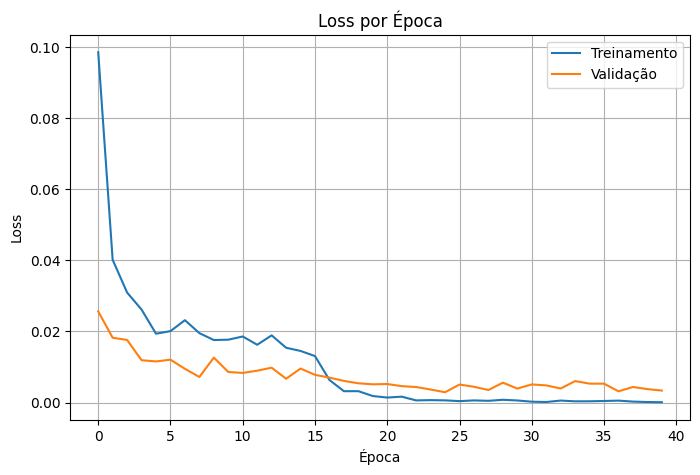

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


 TABELA 5 - PERFORMANCE METRICS (FORMATO CIENTÍFICO)
Architecture   Variant    ACC     Precision               Recall                  F1-Score                AUC                     Specificity            
                                  M       m       W         M       m       W         M       m       W         M       m       W         M       m       W         
-------------------------------------------------------------------------------------------------------------------------------------------------
TransferKAN    Gunshot    1.000   1.000   1.000   1.000     1.000   1.000   1.000     0.999   1.000   0.999     1.000   1.000   1.000     1.000   1.000   1.000  

              precision    recall  f1-score   support

 Entrada (0)       1.00      1.00      1.00      1000
   Saída (1)       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00   

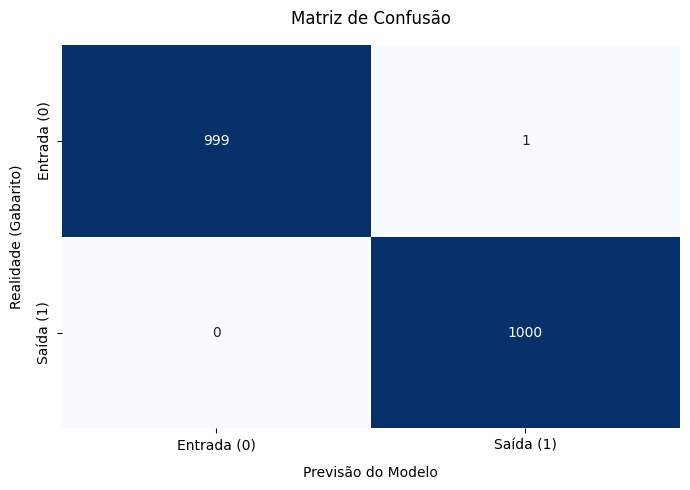

In [14]:

model.eval()

y_true = []
y_pred = []
y_prob_both = []

with torch.no_grad():
    for images, labels in dataloader_test:
        images = images.to(device)
        outputs = model(images)

        # Softmax extrai as probabilidades de ambas as classes
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob_both.extend(probabilities.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob_both = np.array(y_prob_both)

# One-Hot Encoding para permitir AUC multiclasse/simétrico (M, m, W)
y_true_onehot = np.eye(2)[y_true]

classes = ['Entrada (0)', 'Saída (1)']

# ==========================================
# EXTRAÇÃO DE VARIÁVEIS DA MATRIZ DE CONFUSÃO
# ==========================================
cm = confusion_matrix(y_true, y_pred)

# FP, FN, TP e TN extraídos conforme as fórmulas do artigo
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

support_per_class = cm.sum(axis=1)

# ==========================================
# CÁLCULO DE MÉTRICAS (Fórmulas do Artigo)
# ==========================================
acc = accuracy_score(y_true, y_pred)

metrics = {}
averages = ['macro', 'micro', 'weighted']

# Precision, Recall, F1-Score e AUC usando Scikit-Learn (mesma matemática)
for avg in averages:
    metrics[f'Prec_{avg}'] = precision_score(y_true, y_pred, average=avg, zero_division=0)
    metrics[f'Rec_{avg}'] = recall_score(y_true, y_pred, average=avg, zero_division=0)
    metrics[f'F1_{avg}'] = f1_score(y_true, y_pred, average=avg, zero_division=0)
    metrics[f'AUC_{avg}'] = roc_auc_score(y_true_onehot, y_prob_both, average=avg)

# Especificidade: TN / (TN + FP)
specificity_per_class = TN / (TN + FP)

# Macro: Média aritmética pura das classes
metrics['Spec_macro'] = np.mean(specificity_per_class)

# Micro: Soma global de TN e FP
metrics['Spec_micro'] = TN.sum() / (TN.sum() + FP.sum())

# Weighted: Média ponderada pela quantidade de amostras de cada classe
metrics['Spec_weighted'] = np.average(specificity_per_class, weights=support_per_class)


# ==========================================
# GERAÇÃO DA TABELA DO ARTIGO (Console)
# ==========================================
print("\n" + "="*145)
print(" TABELA 5 - PERFORMANCE METRICS (FORMATO CIENTÍFICO)")
print("="*145)

# Cabeçalho Superior
header1 = f"{'Architecture':<14} {'Variant':<10} {'ACC':<7} "
header1 += f"{'Precision':<23} {'Recall':<23} {'F1-Score':<23} {'AUC':<23} {'Specificity':<23}"
print(header1)

# Cabeçalho Inferior (M = Macro, m = micro, W = Weighted)
header2 = f"{'':<33} "
for _ in range(5):
    header2 += f"{'M':<7} {'m':<7} {'W':<7}   "
print(header2)
print("-" * 145)

# Linha do Modelo
row = f"{'TransferKAN':<14} {'Gunshot':<10} {acc:<7.3f} "
row += f"{metrics['Prec_macro']:<7.3f} {metrics['Prec_micro']:<7.3f} {metrics['Prec_weighted']:<7.3f}   "
row += f"{metrics['Rec_macro']:<7.3f} {metrics['Rec_micro']:<7.3f} {metrics['Rec_weighted']:<7.3f}   "
row += f"{metrics['F1_macro']:<7.3f} {metrics['F1_micro']:<7.3f} {metrics['F1_weighted']:<7.3f}   "
row += f"{metrics['AUC_macro']:<7.3f} {metrics['AUC_micro']:<7.3f} {metrics['AUC_weighted']:<7.3f}   "
row += f"{metrics['Spec_macro']:<7.3f} {metrics['Spec_micro']:<7.3f} {metrics['Spec_weighted']:<7.3f}"
print(row)
print("="*145 + "\n")


# ==========================================
# PLOTAGEM DA MATRIZ E RELATÓRIO PADRÃO
# ==========================================
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=False)
plt.title('Matriz de Confusão', pad=15)
plt.xlabel('Previsão do Modelo', labelpad=10)
plt.ylabel('Realidade (Gabarito)', labelpad=10)
plt.tight_layout()
plt.show()